# ANN - Artificial Neural Network

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

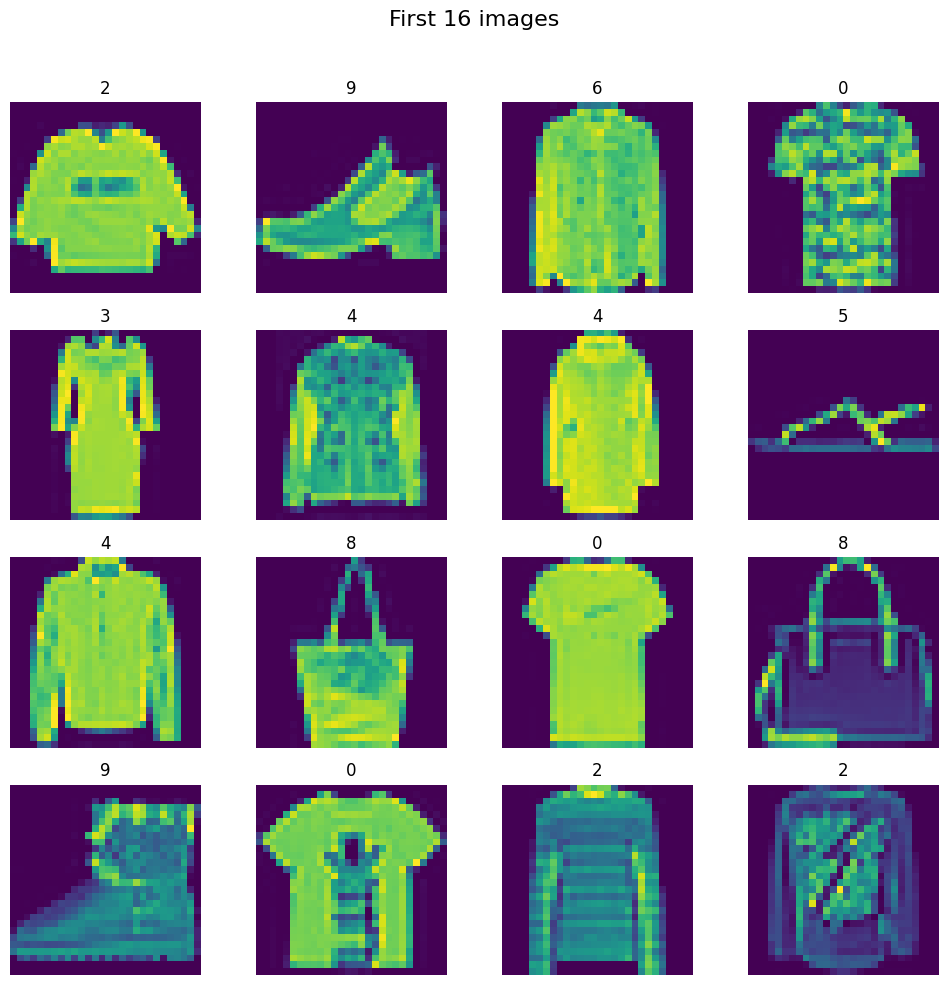

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
fig.suptitle("First 16 images", fontsize=16)
for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(df.iloc[i, 0])
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

## Dataset and DataLoader

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

## Model

In [ ]:
class MyNN(nn.Module):
  def __init__(self, num_features):
    super(MyNN, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    return self.model(x)

In [ ]:
epochs = 100
learning_rate = 0.1

In [ ]:
model = MyNN(X_train.shape[1])
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [ ]:
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)
    outputs = model(batch_features)
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss += loss.item()
  print(f"Epoch: {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_loader)}")

Epoch: 1/100, Loss: 0.6249084657629331
Epoch: 2/100, Loss: 0.49199690653880435
Epoch: 3/100, Loss: 0.45562089485426743
Epoch: 4/100, Loss: 0.43380642544229825
Epoch: 5/100, Loss: 0.41715061584611735
Epoch: 6/100, Loss: 0.40564093277355034
Epoch: 7/100, Loss: 0.3941608931571245
Epoch: 8/100, Loss: 0.38580174928406874
Epoch: 9/100, Loss: 0.3743983890265226
Epoch: 10/100, Loss: 0.3725726637095213
Epoch: 11/100, Loss: 0.36783315147956214
Epoch: 12/100, Loss: 0.3572052289446195
Epoch: 13/100, Loss: 0.35052060889204345
Epoch: 14/100, Loss: 0.3449219484726588
Epoch: 15/100, Loss: 0.34472562207778296
Epoch: 16/100, Loss: 0.33732124184072015
Epoch: 17/100, Loss: 0.3344038988550504
Epoch: 18/100, Loss: 0.3302020480086406
Epoch: 19/100, Loss: 0.33063985937833784
Epoch: 20/100, Loss: 0.3262277270356814
Epoch: 21/100, Loss: 0.3208496819138527
Epoch: 22/100, Loss: 0.3183093272894621
Epoch: 23/100, Loss: 0.3225850373158852
Epoch: 24/100, Loss: 0.31459670132398604
Epoch: 25/100, Loss: 0.31343053522954

## Eval

In [ ]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)
    outputs = model(batch_features)
    _, predicted = torch.max(outputs, 1)
    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()
print(f"Accuracy: {100*correct/total}%")

Accuracy: 88.325%
